# Anisotropic and Degenerate CCA as the Dimension Grows

This notebook explores how the sample canonical correlations between two data matrices $X \in \mathbb R^{n\times p}$ and $Y \in \mathbb{R}^{n\times q}$ evolve as the variable dimension $p$ (and $q$) grows relative to a fixed sample size $n$, in two structural settings that go beyond the simple isotropic model ($\Sigma = \sigma I$):

- **Anisotropic** (full-rank but non-identity) covariance, e.g. AR(1)/Toeplitz or spiked covariance models.
- **Low-rank/degenerate** covariance, where the population covariance of $X$ (and $Y$) is singular and its rank is fixed with respect to $p$ and $q$.

We examine each under two regimes:

1. **Independent vectors (null model):** $X \perp Y$ and so there are no linear correlation directions between them, making all population canonical correlations equal to $0$. Any correlations we observe are spurious.
2. **Linear signal present:** there exists a single direction with population canonical correlation $\rho > 0$ that we hope to recover from the sample data.

#### Definition of CCA


Consider two datasets $\mathbf{X}\in\mathbb{R}^{n\times p}$ and $\mathbf{Y}\in\mathbb{R}^{n\times q}$ where $n$ denotes the number of samples common to both datasets and $p,q$ denote that number of variables in each. In this way, we can understand the data matrices as $n$ i.i.d. realizations of the mean-zero random vectors $X\in \mathbb{R}^p$ and $Y\in \mathbb{R}^q$. The goal in Canonical Correlation Analysis (CCA) is that of finding directions $\mathbf{a}\in \mathbb{R}^p,\, \mathbf{b}\in\mathbb{R}^q$ such that the correlation of $\mathbf{a}^\top X$ and $\mathbf{b}^\top Y$ is maximized.

Let $\Sigma_X = \mathrm{Var}(X)$, $\Sigma_Y = {\rm Var}(Y)$ and $\Sigma_{XY} = \mathrm{Cov}(X,Y) = \mathbb{E}[XY^\top]$. We wish to maximize the expression

\begin{equation}
\rho(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a}^\top\Sigma_{XY}\mathbf{b}}{\sqrt{\mathbf{a}^\top \Sigma_X \mathbf{a}\mathbf{b}^\top \Sigma_Y \mathbf{b}}}.
\end{equation}

In practice we replace these (usually unknown) covariances with their sample counterparts, with the hope that the sample canonical correlations and their directions are good estimators of the population equivalents.

## Setup and helper functions

We implement two CCA routines: `cancor_naive` is the textbook QR+SVD computation inspired by the `stats::cancor` function from `R`. The function `cancor_rankaware` first projects onto the numerically nonzero column space via a thresholded SVD, so it only works with fixed number of directions instead of working with all the available columns. Both return the leading canonical variate (the score vector in $\mathbb{R}^n$), which we compare with the population latent factor to measure how well the true direction is recovered.

We also include a couple of functions for theoretical RMT objects to compare with our simulated correlations. (Is there an accessible reference?)

Finally, we implement functions to generate the random data under several model assumptions, where each have to versions, a null model version, and one with an actual correlation direction:
- `gen_iso`/`gen_signal_iso`: identity covariances, i.e. isotropic Gaussian distributions for $X$ and $Y$.
- `gen_toeplitz`/`gen_signal_toeplitz`: AR(1) process with correlation $\rho = $ `rho_ar` of appropriate sizes.
- `gen_spiked`: we didn't include the signal version of it since it provides no new interesting observations. 
- `gen_lowrank_null`/`gen_signal_lowrank`: a degenerate covariance matrix, meaning its rank is strictly lower than its size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def cancor_naive(X, Y, return_variate=False):
    """Standard CCA via QR + SVD."""
    Xc = X - X.mean(0); Yc = Y - Y.mean(0)
    Qx, _ = np.linalg.qr(Xc)
    Qy, _ = np.linalg.qr(Yc)
    U, s, Vt = np.linalg.svd(Qx.T @ Qy, full_matrices=False)
    if return_variate:
        return s, Qx @ U[:, 0]
    return s

def cancor_rankaware(X, Y, tol=1e-9, return_variate=False):
    """CCA after projecting onto the effective column space, defined as the directions
    with singular value larger than tolerance times the leading sv."""
    Xc = X - X.mean(0); Yc = Y - Y.mean(0)
    Ux, sx, _ = np.linalg.svd(Xc, full_matrices=False)
    Uy, sy, _ = np.linalg.svd(Yc, full_matrices=False)
    rx = int(np.sum(sx > tol * sx[0]))
    ry = int(np.sum(sy > tol * sy[0]))
    Qx, Qy = Ux[:, :rx], Uy[:, :ry]
    U, s, Vt = np.linalg.svd(Qx.T @ Qy, full_matrices=False)
    if return_variate:
        return s, Qx @ U[:, 0]
    return s

# RMT asymptotic helper functions
def bulk_edge(gp, gq):
    """Largest spurious sample canonical correlation (Wachter edge, capped at 1)."""
    a = np.sqrt(gp * (1 - gq)); b = np.sqrt(gq * (1 - gp))
    return np.where(gp + gq >= 1.0, 1.0, a + b)

def detect_threshold(gp, gq):
    """Population correlation above which an outlier emerges."""
    return (gp * gq) ** 0.25

# Data Generating Process functions for null model case
def gen_iso(rng, n, p):
    return rng.standard_normal((n, p))

def gen_toeplitz(rng, n, p, rho_ar=0.7):
    idx = np.arange(p)
    L = np.linalg.cholesky(rho_ar ** np.abs(idx[:, None] - idx[None, :]))
    return rng.standard_normal((n, p)) @ L.T

def gen_spiked(rng, n, p, k=5, spike=15.0):
    Q, _ = np.linalg.qr(rng.standard_normal((p, k)))
    Z = rng.standard_normal((n, p))
    return Z + (np.sqrt(spike) - 1.0) * (Z @ Q) @ Q.T      # Cov = I + (spike-1) Q Q^T

def gen_lowrank_null(rng, n, p, rank):
    U, _ = np.linalg.qr(rng.standard_normal((p, rank)))     # p x rank orthonormal
    return rng.standard_normal((n, rank)) @ U.T             # rank-deficient: rank < p

# Data Generating Process functions for rank 1 correlation case
def gen_signal_iso(rng, n, p, q, rho):
    a = rng.standard_normal(n); b = rng.standard_normal(n)
    X = rng.standard_normal((n, p)); Y = rng.standard_normal((n, q))
    X[:, 0] = a
    Y[:, 0] = rho * a + np.sqrt(1 - rho**2) * b
    return X, Y, a                                          # a = shared latent linear factor

def gen_signal_toeplitz(rng, n, p, q, rho, rho_ar=0.7):
    X, Y, a = gen_signal_iso(rng, n, p, q, rho)
    Lx = np.linalg.cholesky(rho_ar ** np.abs(np.subtract.outer(np.arange(p), np.arange(p))))
    Ly = np.linalg.cholesky(rho_ar ** np.abs(np.subtract.outer(np.arange(q), np.arange(q))))
    # right-multiplication by a full-rank matrix leaves the column space (and the latent) intact
    return X @ Lx.T, Y @ Ly.T, a

def gen_signal_lowrank(rng, n, p, q, rank, rho):
    a = rng.standard_normal(n); b = rng.standard_normal(n)
    Xr = rng.standard_normal((n, rank)); Yr = rng.standard_normal((n, rank))
    Xr[:, 0] = a
    Yr[:, 0] = rho * a + np.sqrt(1 - rho**2) * b
    Ux, _ = np.linalg.qr(rng.standard_normal((p, rank)))
    Uy, _ = np.linalg.qr(rng.standard_normal((q, rank)))
    return Xr @ Ux.T, Yr @ Uy.T, a                         # signal lives inside the rank-r subspace

rng = np.random.default_rng(123)
n = 400
print("setup complete; n =", n)


setup complete; n = 400


## Independent case (Null model $X \perp Y$)

The population canonical correlations are all equal to $0$, or equivalently, the cross-covariance matrix $\Sigma_{XY}$ is block diagonal, where all off-diagonal entries corresponding to the covariance between one variable of $X$ and one of $Y$ are equal to zero. In the following chunk, we track the growth of the largest sample canonical correlation as $\gamma_p = p/n$ increases, while taking $q = p$.

### Full-rank anisotropy is equivalent to the isotropic case

Standard CCA depends only on the **column spaces** of $X$ and $Y$, not on their scale or correlation structure. What is meant by this is that if $X \sim \mathcal{N}(0, \Sigma_X)$, then taking $\tilde{X} = \Sigma_X^{-1/2}X \sim \mathcal{N}(0, I_p)$ is an affine change of basis that has isotropic covariance in the transformed coordinates. This mapping leaves the column space, and every canonical correlation, unchanged, so an isotropic covariance and an anisotropic one, e.g. AR(1)/Toeplitz or spiked covariance, will show identical correlation inflation behaviours. The following code simulates data from three models (isotropic, Toeplitz with $\rho = 0.7$, and 5-spike covariance) and superimposes their canonical correlations in a graph as $p$ increases with respect to $n$.

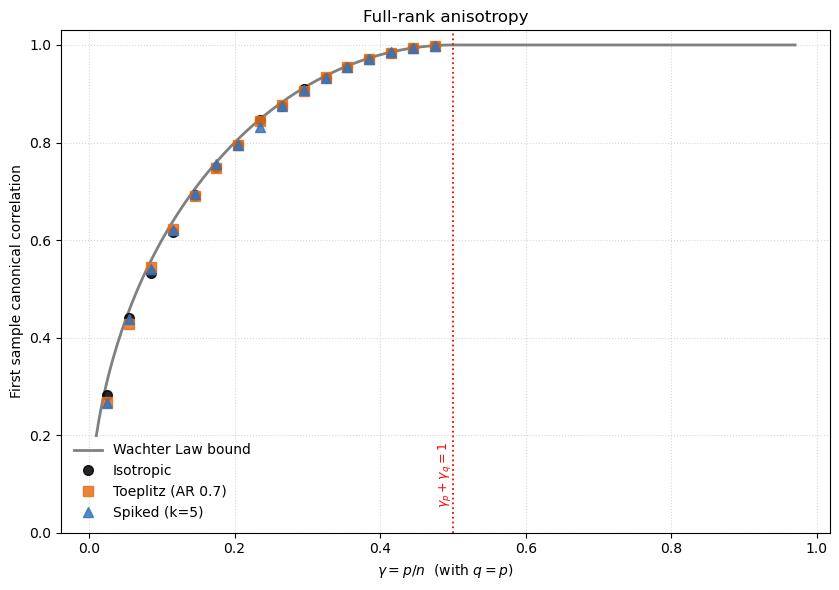

In [2]:
ps = np.arange(10, 196, 12)
reps = 12
gens = {'Isotropic': gen_iso,
        'Toeplitz (AR 0.7)': lambda r, n, p: gen_toeplitz(r, n, p, 0.7),
        'Spiked (k=5)': lambda r, n, p: gen_spiked(r, n, p, 5, 15.0)}
styles = {'Isotropic': ('o', 'black'),
          'Toeplitz (AR 0.7)': ('s', '#e6701b'),
          'Spiked (k=5)': ('^', '#3573b9')}

curves = {name: [] for name in gens}
for p in ps:
    for name, gen in gens.items():
        vals = [cancor_naive(gen(rng, n, p), gen(rng, n, p))[0] for _ in range(reps)]
        curves[name].append(np.mean(vals))

g = ps/n
fig, ax = plt.subplots(figsize=(8.5, 6))
gg = np.linspace(0.01, 0.97, 300)
ax.plot(gg, bulk_edge(gg, gg), '-', color='0.5', lw=2, label='Wachter Law bound')
for name in gens:
    mk, col = styles[name]
    ax.plot(g, curves[name], mk, color=col, ms=7, alpha=0.85, label=name)
ax.axvline(0.5, color='red', ls=':', lw=1.3)
ax.text(0.5, 0.05, r'$\gamma_p+\gamma_q=1$', color='red', rotation=90, va='bottom', ha='right', fontsize=9)
ax.set(xlabel=r'$\gamma = p/n$  (with $q=p$)',
       ylabel='First sample canonical correlation',
       title='Full-rank anisotropy',
       ylim=(0, 1.03))
ax.legend(frameon=False)
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


### Degenerate covariance matrix

We now assume that $X$ and $Y$ have rank-deficient covariances, and so each lives in a random $r$-dimensional subspace, with all other coordinates being equal to zero. We will sample $X,Y$ from Gaussian distributions with mean-zero rank-deficient covariances (we only sample from an $r$-dimensional Gaussian and then multiply by a rank $r$ orthonormal matrix). The following simulation aims to examine the correlation inflation phenomenon in this degenerate covariance case, and as such calculates the canonical correlations as the ambient dimension $p$ grows while keeping $r$ fixed. We will perform CCA in two different ways:

- **Regular CCA** with the function `cancor()`. Note that performing unpivoted QR results in a $Q$ matrix with orthogonal columns that is full rank, which leads to a correlation inflation that increases all the way to $1$ as $p$ grows, even though nothing changed in the data's intrinsic geometry. Importantly, we can observe how the Wachter law is no longer the correct limiting law for this behaviour since we are constraining the set of possible canonical directions.
- **Rank-aware CCA** with the function `cancor_rankaware()` truncates to the true dimension and thus the canonical correlations are bounded by an effective inflation $\rho_{\text{bulk}}(r/n)$, and as such do not increase up to 1 but stay at that point even as $p$ increases.

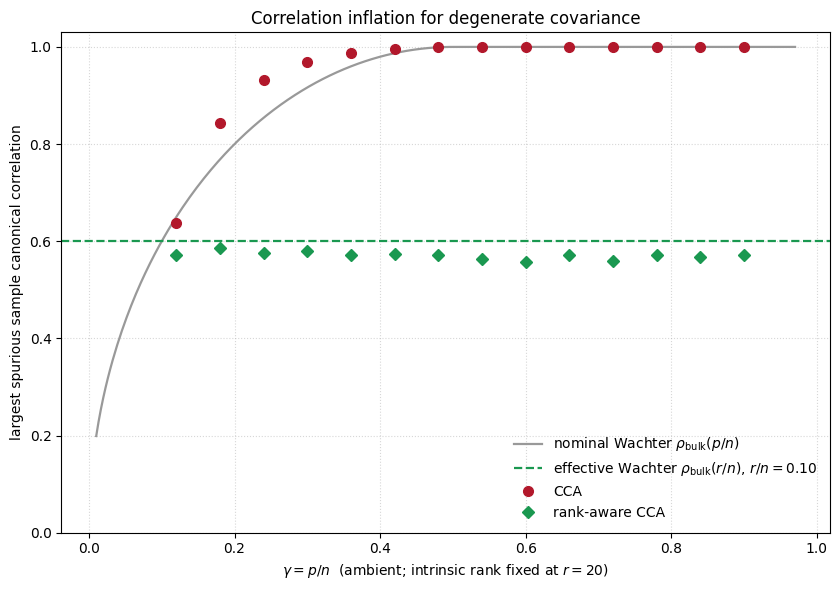

In [39]:
n = 200
r_fixed = 20
ps = np.arange(24, 192, 12)
reps = 12
naive_c, rank_c = [], []
for p in ps:
    nv = [cancor_naive(gen_lowrank_null(rng, n, p, r_fixed),
                       gen_lowrank_null(rng, n, p, r_fixed))[0] for _ in range(reps)]
    ra = [cancor_rankaware(gen_lowrank_null(rng, n, p, r_fixed),
                           gen_lowrank_null(rng, n, p, r_fixed))[0] for _ in range(reps)]
    naive_c.append(np.mean(nv)); rank_c.append(np.mean(ra))

g = ps/n
g_eff = r_fixed/n
fig, ax = plt.subplots(figsize=(8.5, 6))
gg = np.linspace(0.01, 0.97, 300)
ax.plot(gg, bulk_edge(gg, gg), '-', color='0.6', lw=1.6, label=r'nominal Wachter $\rho_{\rm bulk}(p/n)$')
ax.axhline(bulk_edge(g_eff, g_eff), color='#1a9850', ls='--', lw=1.6,
           label=fr'effective Wachter $\rho_{{\rm bulk}}(r/n)$, $r/n={g_eff:.2f}$')
ax.plot(g, naive_c, 'o', color='#b2182b', ms=7, label='CCA')
ax.plot(g, rank_c, 'D', color='#1a9850', ms=6, label='rank-aware CCA')
ax.set(xlabel=r'$\gamma = p/n$  (ambient; intrinsic rank fixed at $r=20$)',
       ylabel='largest spurious sample canonical correlation',
       title='Correlation inflation for degenerate covariance',
       ylim=(0, 1.03))
ax.legend(frameon=False, loc='lower right')
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


## CCA with a correlation signal present

We now include a single direction with population canonical correlation $\rho>0$ via a shared latent factor (see `gen_signal_*` functions). The question is whether CCA can recover this signal from the samples, and how is this recovery affected by the number of variables present. We track two quantities, the **first sample canonical correlation**, and the **alignment** of the recovered canonical variate with the true latent factor, defined as $|\mathrm{corr}(\hat\xi, a)|$ (the dot product beetween them), which is $\approx 1$ when the direction is found and $\approx 1/\sqrt{n}$ when it is lost.

### Full-rank case

Fixing $\rho = 0.6$ and taking $q=p$ increasing, the theoretical detection threshold is $\rho_c = \sqrt{\gamma}$, which is an increasing function of $\gamma$. When $\rho_c < \rho$ (here $\gamma < \rho^2 = 0.36$) the signal stands out as an outlier
and its direction is recovered by CCA. When $\rho_c > \rho$, the signal disappears into the bulk and CCA is no longer able to recover the direction. This can be seen by the decrease in the value of the alignment. This behaviour is the same across the isotropic and Toeplitz cases, since the presence of anisotropy does not affect the the mechanism at work.

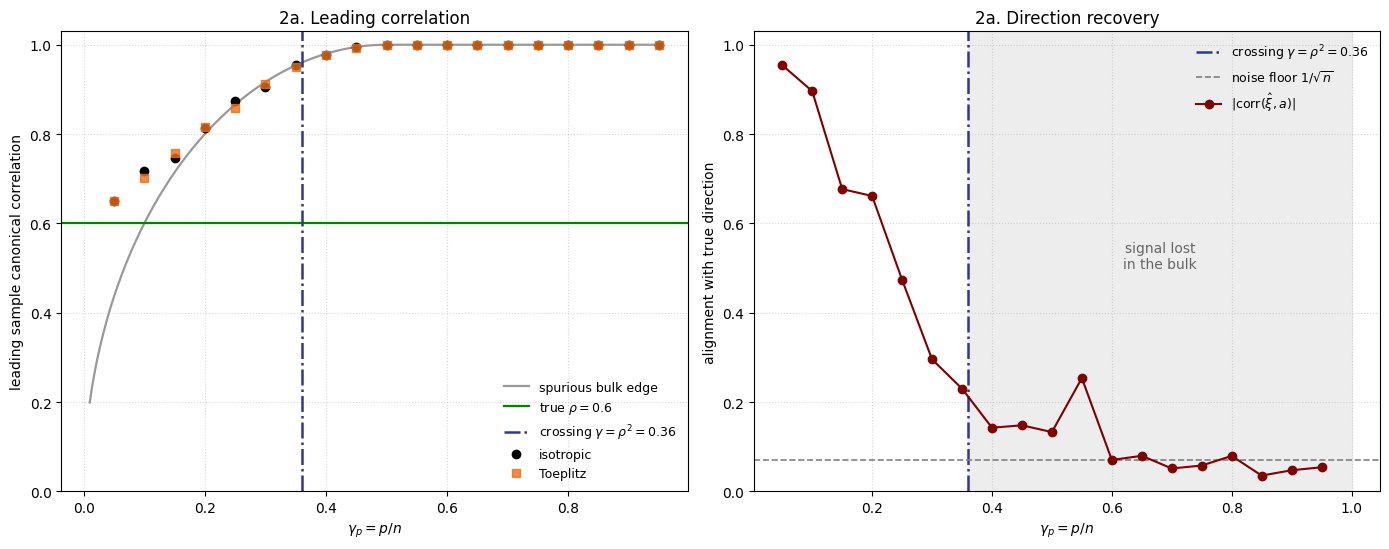

In [42]:
rho = 0.6
ps = np.arange(10, 191, 10)
reps = 14
top_iso, top_toe, ali_iso = [], [], []
for p in ps:
    ti, tt, ai = [], [], []
    for _ in range(reps):
        X, Y, a = gen_signal_iso(rng, n, p, p, rho)
        s, xi = cancor_naive(X, Y, return_variate=True)
        ti.append(s[0]); ai.append(abs(np.corrcoef(xi, a)[0, 1]))
        Xt, Yt, _ = gen_signal_toeplitz(rng, n, p, p, rho, 0.7)
        tt.append(cancor_naive(Xt, Yt)[0])
    top_iso.append(np.mean(ti)); top_toe.append(np.mean(tt)); ali_iso.append(np.mean(ai))

g = ps / n
g_cross = rho**2          # sqrt(g) = rho  ->  g = rho^2
gg = np.linspace(0.01, 0.95, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax = axes[0]
ax.plot(gg, bulk_edge(gg, gg), '-', color='0.6', lw=1.6, label=r'spurious bulk edge')
ax.axhline(rho, color='green', ls='-', lw=1.6, label=fr'true $\rho={rho}$')
ax.axvline(g_cross, color='#313695', ls='-.', lw=1.8, label=fr'crossing $\gamma=\rho^2={g_cross:.2f}$')
ax.plot(g, top_iso, 'o', color='black', ms=6, label='isotropic')
ax.plot(g, top_toe, 's', color='#e6701b', ms=6, alpha=0.8, label='Toeplitz')
ax.set(xlabel=r'$\gamma_p=p/n$', ylabel='leading sample canonical correlation',
       title='2a. Leading correlation', ylim=(0, 1.03))
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(True, ls=':', alpha=0.5)

ax = axes[1]
ax.axvspan(g_cross, 1, color='0.93', zorder=0)
ax.axvline(g_cross, color='#313695', ls='-.', lw=1.8, label=fr'crossing $\gamma=\rho^2={g_cross:.2f}$')
ax.axhline(1/np.sqrt(n), color='gray', ls='--', lw=1.2, label=r'noise floor $1/\sqrt{n}$')
ax.plot(g, ali_iso, 'o-', color='#7f0000', ms=6, label=r'$|\mathrm{corr}(\hat\xi, a)|$')
ax.text((g_cross+1)/2, 0.5, 'signal lost\nin the bulk', ha='center', color='0.4', fontsize=10)
ax.set(xlabel=r'$\gamma_p=p/n$', ylabel='alignment with true direction',
       title='2a. Direction recovery', ylim=(0, 1.03))
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


### Low-rank case

We now define the signal ($\rho = 0.5$) to live within a rank-$20$ subspace embedded within $p$-dimensional space. Instead of a detection threshold affected by $p$, we can instead think of an effective threshold $\rho_c=\sqrt{r/n}=\sqrt{0.1}\approx 0.32 < 0.5$, so the signal is detectable irrespective of the ambient dimension $p$. The Rank-aware CCA procedure exploits this by ignoring the irrelevant directions. The leading canonical correlation calculated in this way remains an outlier as $p$ increases and the alignment of the sample canonical direction and the ground truth also stays high. In short, rank-awareness is able to recover a signal that is lost when direct CCA is applied.

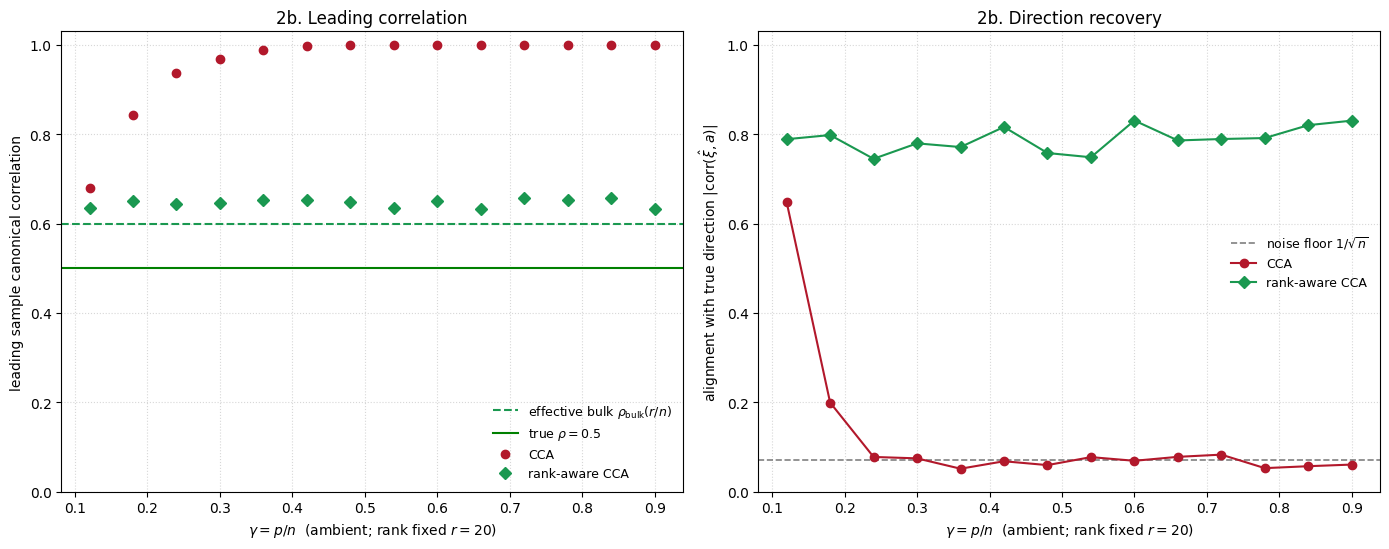

In [45]:
rho, r_fixed = 0.5, 20
ps = np.arange(24, 191, 12)
reps = 14
nv_top, ra_top, nv_ali, ra_ali = [], [], [], []
for p in ps:
    nt, rt, na, ra_ = [], [], [], []
    for _ in range(reps):
        X, Y, a = gen_signal_lowrank(rng, n, p, p, r_fixed, rho)
        s1, xi1 = cancor_naive(X, Y, return_variate=True)
        s2, xi2 = cancor_rankaware(X, Y, return_variate=True)
        nt.append(s1[0]); na.append(abs(np.corrcoef(xi1, a)[0, 1]))
        rt.append(s2[0]); ra_.append(abs(np.corrcoef(xi2, a)[0, 1]))
    nv_top.append(np.mean(nt)); ra_top.append(np.mean(rt))
    nv_ali.append(np.mean(na)); ra_ali.append(np.mean(ra_))

g = ps / n
g_eff = r_fixed / n
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

ax = axes[0]
ax.axhline(bulk_edge(g_eff, g_eff), color='#1a9850', ls='--', lw=1.5,
           label=fr'effective bulk $\rho_{{\rm bulk}}(r/n)$')
ax.axhline(rho, color='green', ls='-', lw=1.5, label=fr'true $\rho={rho}$')
ax.plot(g, nv_top, 'o', color='#b2182b', ms=6, label='CCA')
ax.plot(g, ra_top, 'D', color='#1a9850', ms=6, label='rank-aware CCA')
ax.set(xlabel=r'$\gamma=p/n$  (ambient; rank fixed $r=20$)',
       ylabel='leading sample canonical correlation',
       title='2b. Leading correlation', ylim=(0, 1.03))
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(True, ls=':', alpha=0.5)

ax = axes[1]
ax.axhline(1/np.sqrt(n), color='gray', ls='--', lw=1.2, label=r'noise floor $1/\sqrt{n}$')
ax.plot(g, nv_ali, 'o-', color='#b2182b', ms=6, label='CCA')
ax.plot(g, ra_ali, 'D-', color='#1a9850', ms=6, label='rank-aware CCA')
ax.set(xlabel=r'$\gamma=p/n$  (ambient; rank fixed $r=20$)',
       ylabel=r'alignment with true direction $|\mathrm{corr}(\hat\xi,a)|$',
       title='2b. Direction recovery', ylim=(0, 1.03))
ax.legend(frameon=False, fontsize=9, loc='center right')
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()
